In [ ]:
## dataset creation - generate training images
## Converts strain data into Q-transform spectrogram images for CNN training

In [9]:
from gwpy.timeseries import TimeSeries
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import shutil

BASE_DIR    = r'C:\Users\srika\gw_wd'
EVENTS_DIR  = os.path.join(BASE_DIR, 'data', 'events')
NOISE_DIR   = os.path.join(BASE_DIR, 'data', 'noise')
DATASET_DIR = os.path.join(BASE_DIR, 'data', 'dataset_qtransform')

# Clean start
if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

os.makedirs(os.path.join(DATASET_DIR, 'signal'), exist_ok=True)
os.makedirs(os.path.join(DATASET_DIR, 'noise'),  exist_ok=True)

print(" Setup complete")
print(f" New dataset will be saved to: {DATASET_DIR}")

 Setup complete
 New dataset will be saved to: C:\Users\srika\gw_wd\data\dataset_qtransform


In [10]:
def make_qtransform_image(data, sr, gps_center, save_path=None):
    """
    Create Q-transform spectrogram image
    This is what LIGO scientists actually use!
    """
    
    # Convert to gwpy TimeSeries
    ts = TimeSeries(data, t0=gps_center-16, sample_rate=sr, unit='strain')
    
    # Compute Q-transform (zoomed to ±1 second around center)
    qgram = ts.q_transform(
        frange=(20, 400),
        qrange=(4, 64),
        outseg=(gps_center - 1, gps_center + 1),
        logf=True,
        whiten=True
    )
    
    # Extract arrays
    t_vals = qgram.times.value - gps_center
    f_vals = qgram.frequencies.value
    power  = qgram.value
    
    # Create clean image (224x224, no axes)
    fig = plt.figure(figsize=(2.24, 2.24), dpi=100)
    ax  = fig.add_axes([0, 0, 1, 1])
    
    ax.pcolormesh(t_vals, f_vals, power.T,
                  cmap='viridis',
                  shading='auto',
                  vmin=0, vmax=25)
    ax.set_yscale('log')
    ax.set_ylim([20, 400])
    ax.axis('off')
    
    if save_path:
        plt.savefig(save_path, dpi=100,
                    bbox_inches='tight', pad_inches=0)
    
    # Convert to array
    fig.canvas.draw()
    buf = fig.canvas.tostring_rgb()
    img = np.frombuffer(buf, dtype=np.uint8)
    img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)
    
    return img

print(" Q-transform image generator ready!")

 Q-transform image generator ready!


In [11]:
event_files = sorted([f for f in glob.glob(os.path.join(EVENTS_DIR, '*.npy'))
                      if 'meta' not in f])


print("GENERATING SIGNAL IMAGES WITH Q-TRANSFORM\n")

print(f"Events: {len(event_files)}\n")

signal_count = 0
signal_dir   = os.path.join(DATASET_DIR, 'signal')

for filepath in event_files:
    filename = os.path.basename(filepath).replace('.npy', '')
    print(f"\n{filename}:")
    
    # Load
    data = np.load(filepath)
    meta = np.load(filepath.replace('.npy', '_meta.npy'),
                   allow_pickle=True).item()
    sr   = int(meta['sample_rate'])
    gps  = float(meta['gps_time'])
    
    # Generate 3 images with slight time offsets
    offsets = [0, 0.1, -0.1]
    
    for i, offset in enumerate(offsets):
        gps_center = gps + offset
        save_path  = os.path.join(signal_dir, f'{filename}_q{i}.png')
        
        try:
            print(f"  Q-transform {i}...", end=' ', flush=True)
            make_qtransform_image(data, sr, gps_center, save_path)
            signal_count += 1
            print("done")
        except Exception as e:
            print(f" {str(e)[:40]}")


print(f" Signal images: {signal_count}")


GENERATING SIGNAL IMAGES WITH Q-TRANSFORM

Events: 8


GW150914_H1:
  Q-transform 0... done
  Q-transform 1... 

C:\Users\srika\AppData\Local\Temp\ipykernel_9540\3549876800.py:42: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  buf = fig.canvas.tostring_rgb()


done
  Q-transform 2... done

GW150914_L1:
  Q-transform 0... done
  Q-transform 1... done
  Q-transform 2... done

GW151226_H1:
  Q-transform 0... done
  Q-transform 1... done
  Q-transform 2... done

GW151226_L1:
  Q-transform 0... done
  Q-transform 1... done
  Q-transform 2... done

GW170814_H1:
  Q-transform 0... done
  Q-transform 1... done
  Q-transform 2... done

GW170814_L1:
  Q-transform 0... done
  Q-transform 1... done
  Q-transform 2... done

GW170817_H1:
  Q-transform 0... done
  Q-transform 1... done
  Q-transform 2... done

GW170817_L1:
  Q-transform 0... done
  Q-transform 1... done
  Q-transform 2... done
 Signal images: 24


In [12]:
noise_files = sorted([f for f in glob.glob(os.path.join(NOISE_DIR, '*.npy'))
                      if 'meta' not in f])


print("GENERATING NOISE IMAGES WITH Q-TRANSFORM\n")

print(f"Noise segments: {len(noise_files)}\n")

noise_count = 0
noise_dir   = os.path.join(DATASET_DIR, 'noise')

for filepath in noise_files:
    filename = os.path.basename(filepath).replace('.npy', '')
    
    # Load
    data = np.load(filepath)
    meta = np.load(filepath.replace('.npy', '_meta.npy'),
                   allow_pickle=True).item()
    sr   = int(meta['sample_rate'])
    gps  = float(meta['gps_time'])
    
    # Generate 2 images from different parts
    for i in range(2):
        gps_center = gps + 4 + (i * 8)  # Different time windows
        save_path  = os.path.join(noise_dir, f'{filename}_q{i}.png')
        
        try:
            make_qtransform_image(data, sr, gps_center, save_path)
            noise_count += 1
        except Exception as e:
            pass
    
    print(f"   {filename}: 2 images")


print(f" Noise images: {noise_count}\n")


GENERATING NOISE IMAGES WITH Q-TRANSFORM

Noise segments: 14

   noise_001_H1: 2 images


C:\Users\srika\AppData\Local\Temp\ipykernel_9540\3549876800.py:42: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  buf = fig.canvas.tostring_rgb()


   noise_001_L1: 2 images
   noise_002_H1: 2 images
   noise_002_L1: 2 images
   noise_003_H1: 2 images
   noise_003_L1: 2 images
   noise_004_H1: 2 images
   noise_004_L1: 2 images
   noise_006_H1: 2 images
   noise_007_L1: 2 images
   noise_008_H1: 2 images
   noise_008_L1: 2 images
   noise_009_H1: 2 images
   noise_009_L1: 2 images
 Noise images: 24



Signal images: 24
Noise images : 24


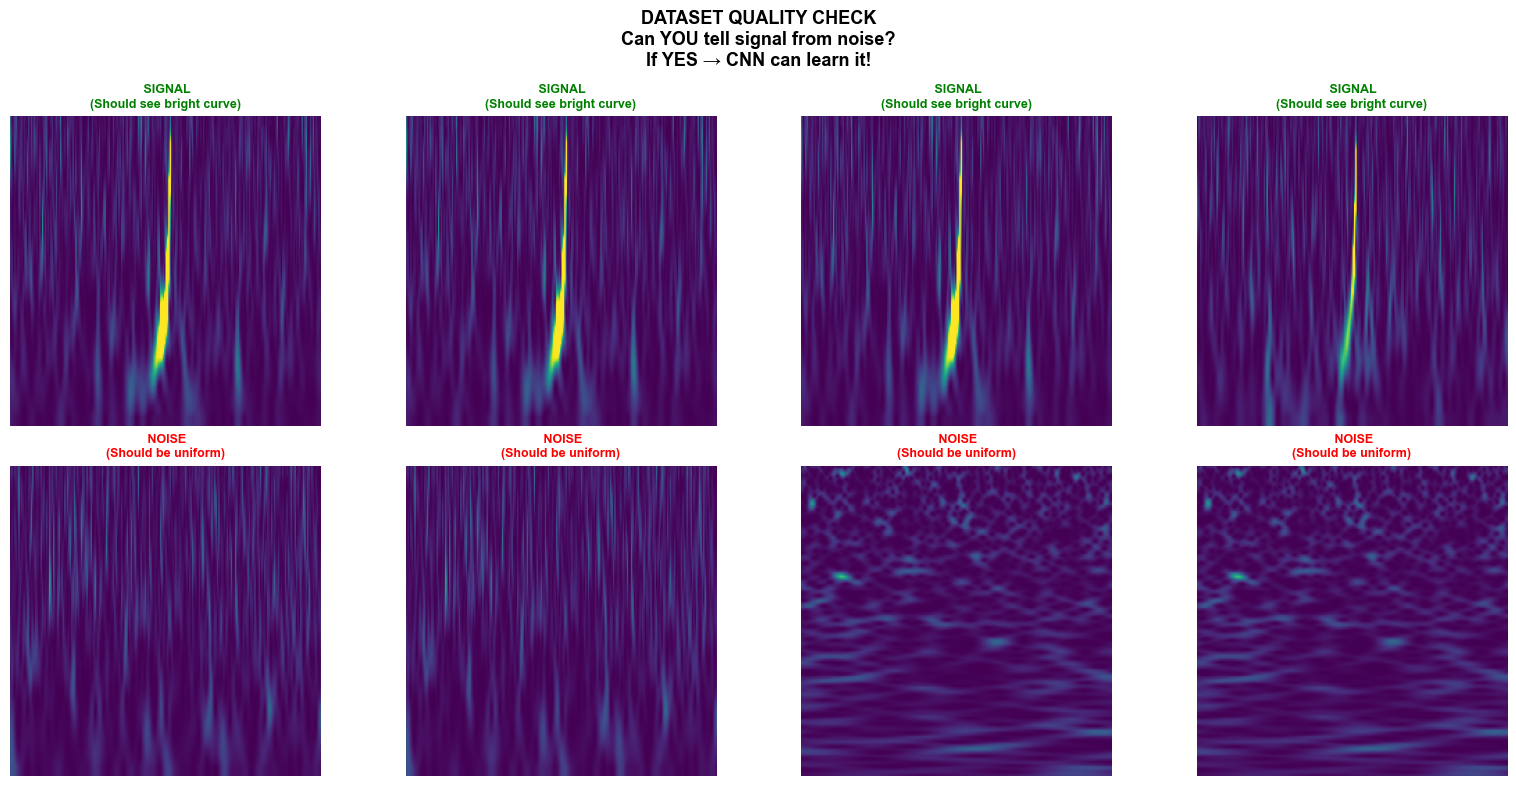


❓ Question: Can you see a difference?
   Signal: Should have bright curved/blob pattern
   Noise : Should look more random/uniform


In [13]:
signal_imgs = sorted(glob.glob(os.path.join(signal_dir, '*.png')))
noise_imgs  = sorted(glob.glob(os.path.join(noise_dir, '*.png')))

print(f"Signal images: {len(signal_imgs)}")
print(f"Noise images : {len(noise_imgs)}")

# Show comparison
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    # Signal
    img = plt.imread(signal_imgs[i])
    axes[0, i].imshow(img)
    axes[0, i].set_title(' SIGNAL\n(Should see bright curve)',
                          fontsize=9, color='green', fontweight='bold')
    axes[0, i].axis('off')
    
    # Noise
    img = plt.imread(noise_imgs[i])
    axes[1, i].imshow(img)
    axes[1, i].set_title(' NOISE\n(Should be uniform)',
                          fontsize=9, color='red', fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle('DATASET QUALITY CHECK\n'
             'Can YOU tell signal from noise?\n'
             'If YES → CNN can learn it!',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n❓ Question: Can you see a difference?")
print("   Signal: Should have bright curved/blob pattern")
print("   Noise : Should look more random/uniform")

In [14]:
#create new training arrays from now on

In [15]:
from PIL import Image
import numpy as np


print("CREATING TRAINING ARRAYS FROM Q-TRANSFORM IMAGES\n")


IMG_SIZE = 224

def load_images(image_paths, label):
    X, y = [], []
    for path in image_paths:
        try:
            img = Image.open(path).convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            arr = np.array(img) / 255.0
            X.append(arr)
            y.append(label)
        except Exception as e:
            print(f"Error: {os.path.basename(path)}")
    return X, y

# Load signal (label=1)
print("\nLoading signal images...", end=' ', flush=True)
X_sig, y_sig = load_images(signal_imgs, label=1)
print(f" {len(X_sig)}")

# Load noise (label=0)
print("Loading noise images...", end=' ', flush=True)
X_noi, y_noi = load_images(noise_imgs, label=0)
print(f" {len(X_noi)}")

# Combine
X = np.array(X_sig + X_noi, dtype=np.float32)
y = np.array(y_sig + y_noi, dtype=np.int32)

print(f"\n Dataset:")
print(f"   Total samples: {len(X)}")
print(f"   Signal (1)   : {np.sum(y==1)}")
print(f"   Noise (0)    : {np.sum(y==0)}")

# Shuffle
np.random.seed(42)
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]

# 80/20 split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"\n Split:")
print(f"   Train: {len(X_train)} (signal={np.sum(y_train==1)}, noise={np.sum(y_train==0)})")
print(f"   Test : {len(X_test)} (signal={np.sum(y_test==1)}, noise={np.sum(y_test==0)})")

# Save
np.save(os.path.join(DATASET_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(DATASET_DIR, 'X_test.npy'),  X_test)
np.save(os.path.join(DATASET_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(DATASET_DIR, 'y_test.npy'),  y_test)

print(f"\n Arrays saved to: {DATASET_DIR}")
print(f"\n Ready to train improved model!")

CREATING TRAINING ARRAYS FROM Q-TRANSFORM IMAGES


Loading signal images...  24
Loading noise images...  24

 Dataset:
   Total samples: 48
   Signal (1)   : 24
   Noise (0)    : 24

 Split:
   Train: 38 (signal=18, noise=20)
   Test : 10 (signal=6, noise=4)

 Arrays saved to: C:\Users\srika\gw_wd\data\dataset_qtransform

 Ready to train improved model!


C:\Users\srika\AppData\Local\Temp\ipykernel_9540\2914266892.py:20: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()


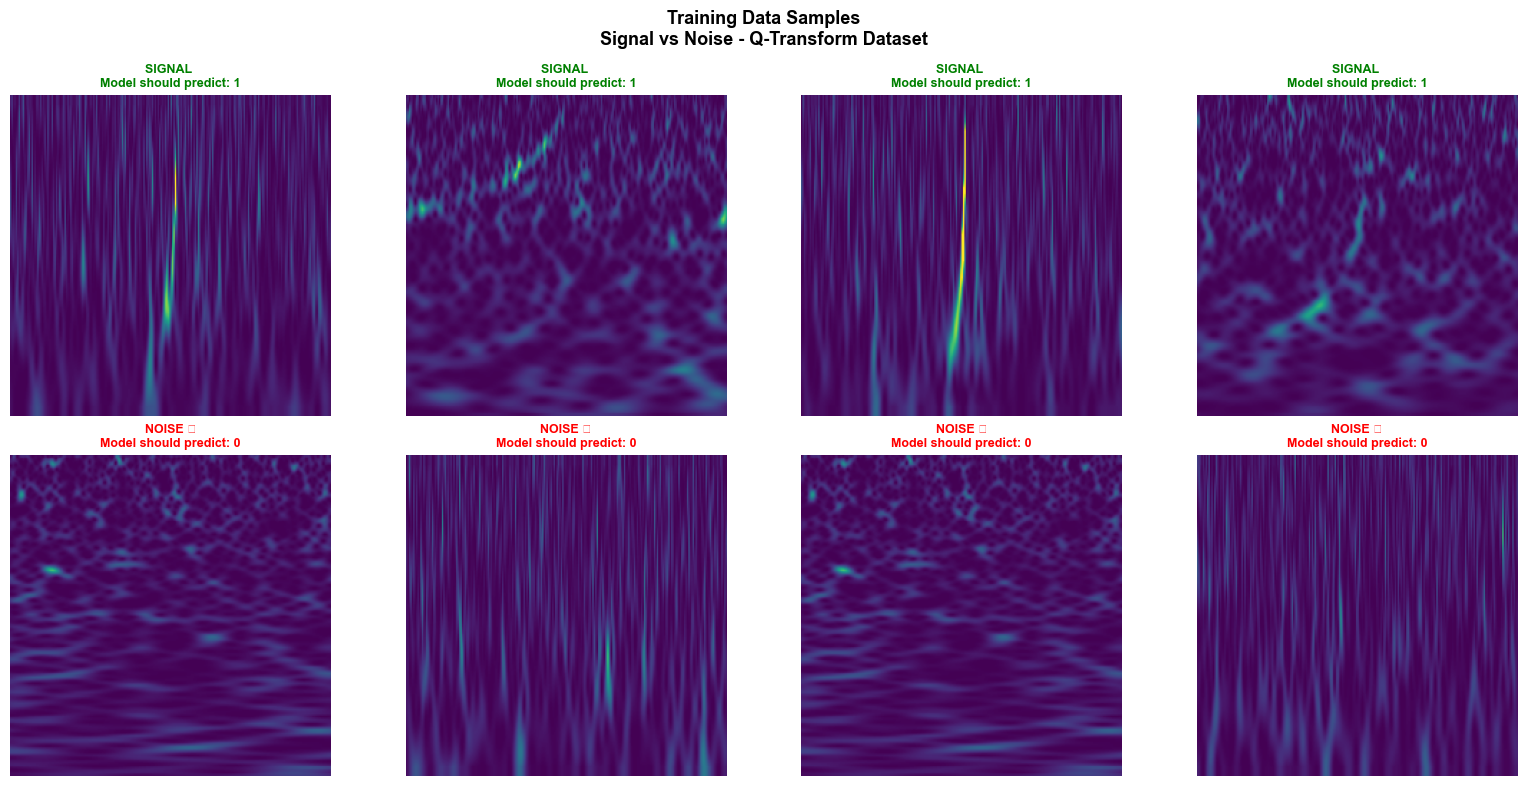

 Dataset ready!


In [16]:
# Show what the model will see
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    # Signal samples
    axes[0, i].imshow(X_train[y_train==1][i])
    axes[0, i].set_title('SIGNAL \nModel should predict: 1',
                          fontsize=9, color='green', fontweight='bold')
    axes[0, i].axis('off')
    
    # Noise samples
    noise_idx = np.where(y_train==0)[0][i]
    axes[1, i].imshow(X_train[noise_idx])
    axes[1, i].set_title('NOISE ❌\nModel should predict: 0',
                          fontsize=9, color='red', fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle('Training Data Samples\nSignal vs Noise - Q-Transform Dataset',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(" Dataset ready!")